KNN Algorithm implementation

In [1]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: c:\Users\Tanvir\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [2]:
%pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: c:\Users\Tanvir\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [3]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: c:\Users\Tanvir\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [4]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: c:\Users\Tanvir\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('mobile.csv')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [ ]:
purchased_data = df[["Age","EstimatedSalary","Purchased"]][df["Purchased"]==1]
purchased_data

,Age,EstimatedSalary,Purchased
7,32,150000,1
16,47,25000,1
17,45,26000,1
18,46,28000,1
19,48,29000,1
...,...,...,...
393,60,42000,1
395,46,41000,1
396,51,23000,1
397,50,20000,1


In [ ]:
not_purchased_data = df[["Age","EstimatedSalary","Purchased"]][df["Purchased"]==0]
not_purchased_data

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
377,42,53000,0
380,42,64000,0
387,39,71000,0
394,39,59000,0


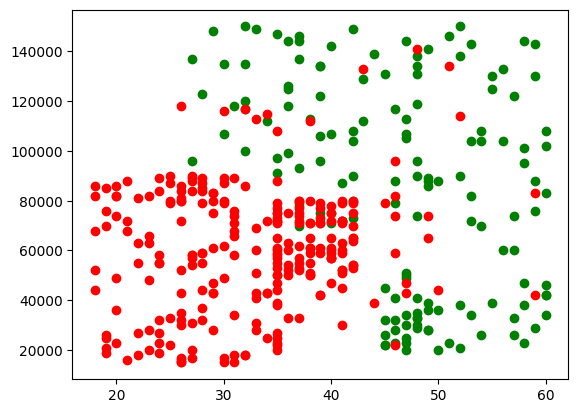

In [ ]:
plt.scatter(purchased_data["Age"],purchased_data["EstimatedSalary"],c="green")
plt.scatter(not_purchased_data["Age"],not_purchased_data["EstimatedSalary"],c="red")

In [ ]:
df['EstimatedSalary'].max()

np.int64(150000)

In [ ]:
df['EstimatedSalary'].min()

np.int64(15000)

In [ ]:
df['Age'].max()

np.int64(60)

In [ ]:
df['Age'].min()

np.int64(18)

In [ ]:
#Here you can normalize the Age and EstimatedSalary columns in the data.
#applying MinMaxScaler to the default dataset

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
features_to_scale = ["Age","EstimatedSalary"]
scaled_values = scaler.fit_transform(df[features_to_scale])
df["norm_Age"] = scaled_values[:,0]
df["norm_Salary"] = scaled_values[:,1]
df.head()


,Age,EstimatedSalary,Purchased,norm_Age,norm_Salary
0,19,19000,0,0.023810,0.029630
1,35,20000,0,0.404762,0.037037
2,26,43000,0,0.190476,0.207407
3,27,57000,0,0.214286,0.311111
4,19,76000,0,0.023810,0.451852


In [ ]:
from sklearn.model_selection import train_test_split
#selecting the predicators and target
X=df[['norm_Age','norm_Salary']]
y=df['Purchased']
#splitting data into train and test data set
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=100)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
#knn with k = 5
model = KNeighborsClassifier(n_neighbors=5,metric="euclidean")
model.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
#Find accuracy of train data and test data
model.score(X_train,y_train) * 100

93.75

In [ ]:
model.score(X_test,y_test) * 100

90.0

In [ ]:
iris_data = pd.read_csv("data/iris.csv")

In [ ]:
v_nv_fn =lambda x:0  if x =="versicolor" else 1
iris_data["v_nv"] = iris_data["Species"].apply(v_nv_fn)
df

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [ ]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import seaborn as sns


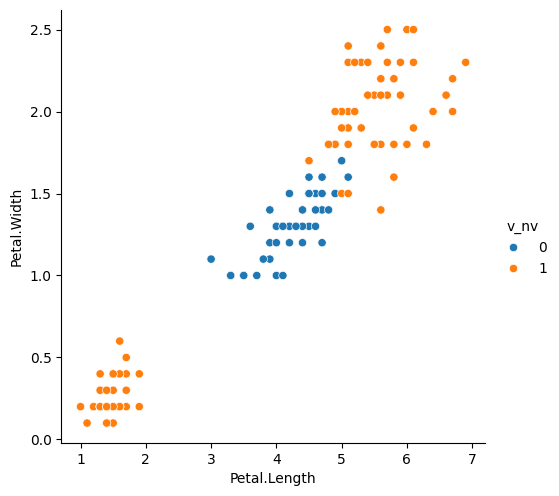

In [ ]:
sns.pairplot(iris_data, x_vars="Petal.Length", y_vars="Petal.Width", hue="v_nv", height=5)